# 04 — Sales Forecast (Prophet)

Aggregate daily revenue, evaluate on a 30-day holdout, then forecast 90 days ahead.

In [1]:
import sys, pandas as pd
from sqlalchemy import create_engine
sys.path.append('../src')
from forecast import daily_revenue, fit_prophet, evaluate_holdout

engine = create_engine('sqlite:///../data/ecommerce.db')
df = pd.read_sql('SELECT order_purchase_timestamp, revenue FROM master', engine, parse_dates=['order_purchase_timestamp'])
daily = daily_revenue(df)
daily.tail()

,ds,y
725,2018-08-30,0.00
726,2018-08-31,0.00
727,2018-09-01,0.00
728,2018-09-02,0.00
729,2018-09-03,166.46


## Holdout evaluation

In [2]:
evaluate_holdout(daily, holdout_days=30)

15:14:04 - cmdstanpy - INFO - Chain [1] start processing
15:14:05 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 17660.02842437428, 'RMSE': 22208.156857761616, 'MAPE': 488955.72199821}

## Fit + 90-day forecast

15:14:05 - cmdstanpy - INFO - Chain [1] start processing
15:14:05 - cmdstanpy - INFO - Chain [1] done processing


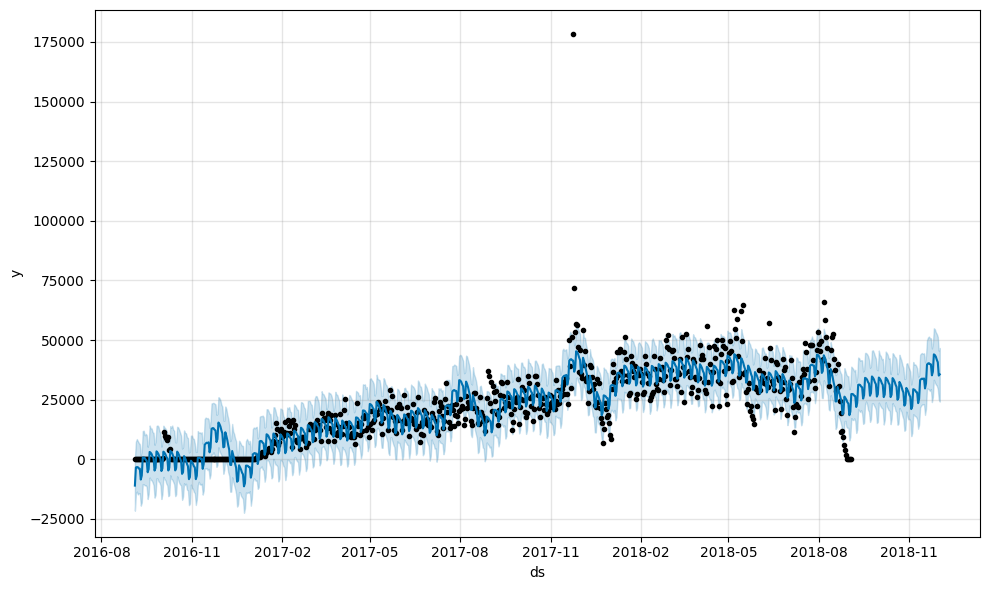

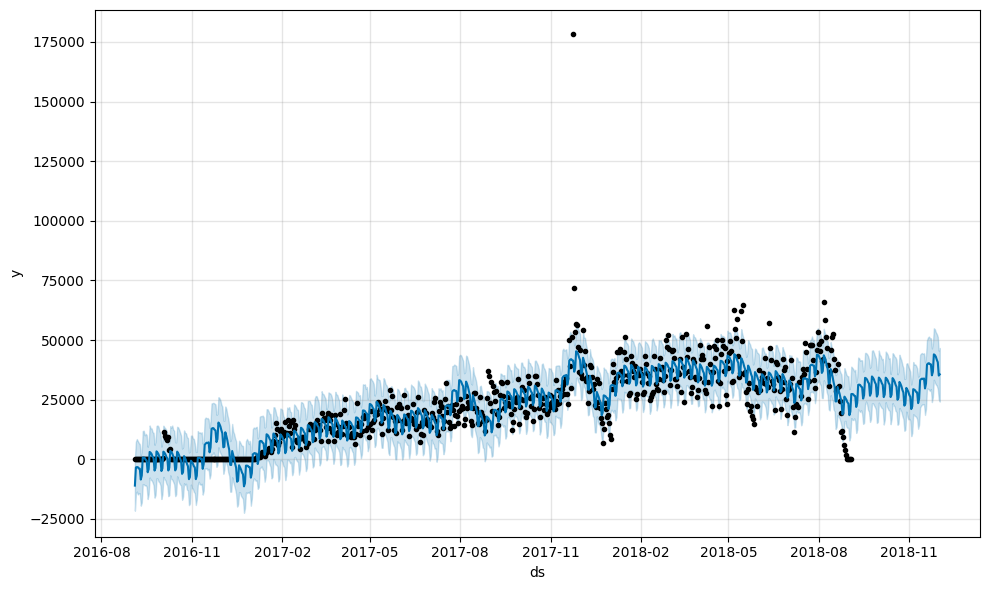

In [3]:
m, fc = fit_prophet(daily, periods=90)
fig = m.plot(fc); fig


## Components

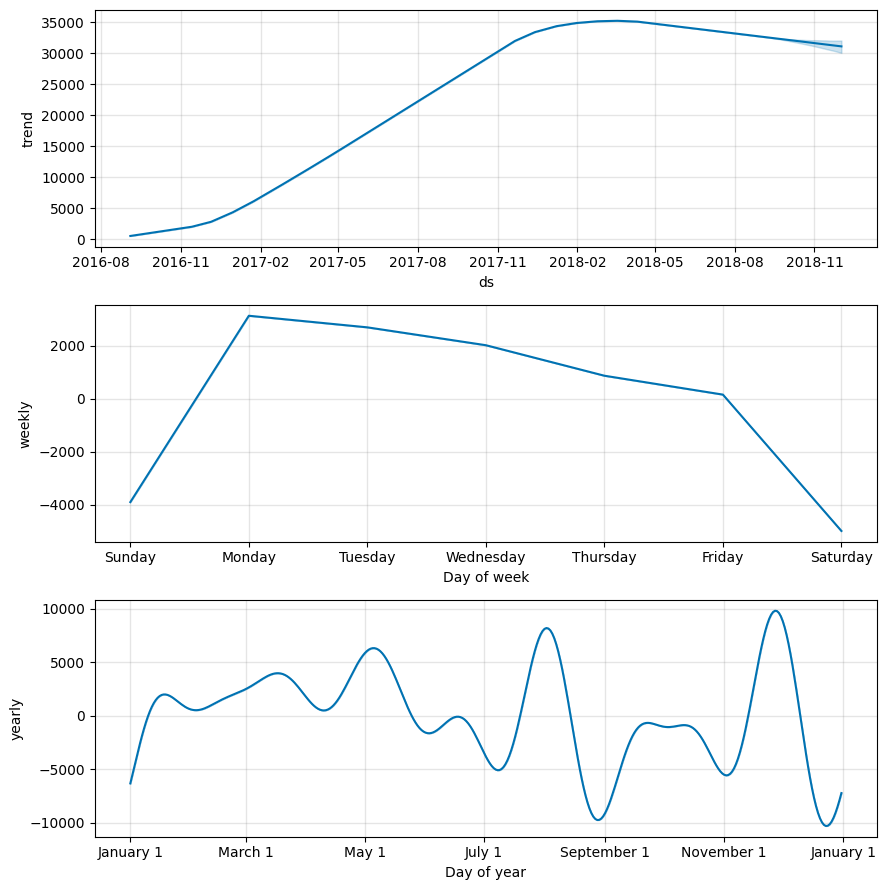

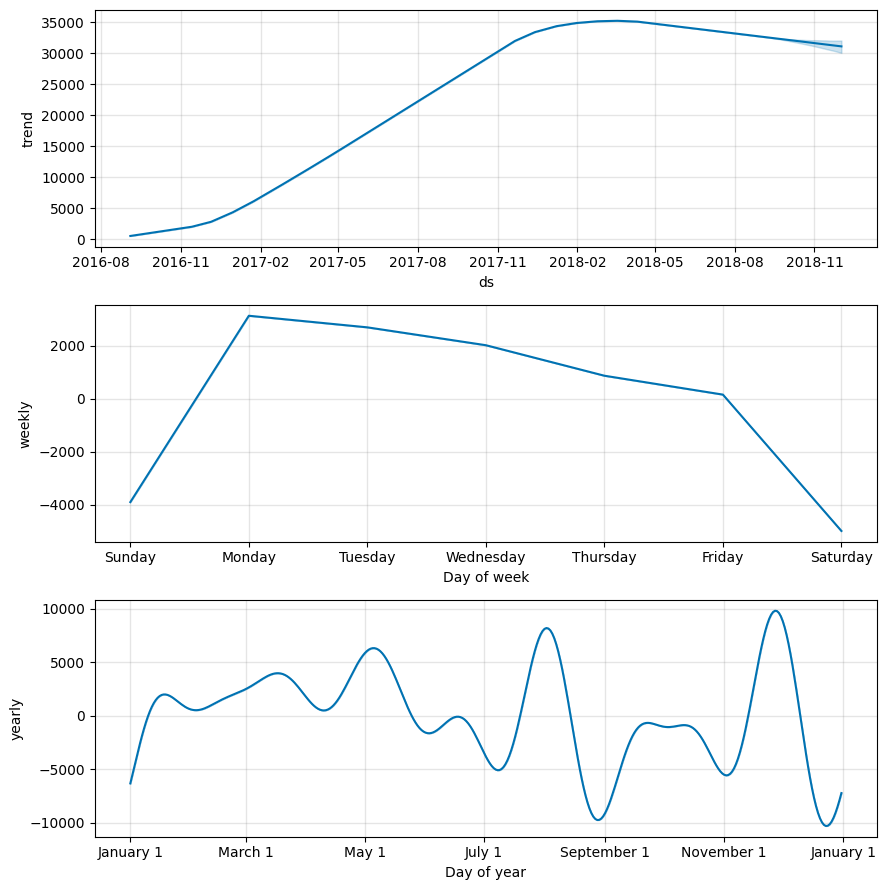

In [4]:
m.plot_components(fc)

In [5]:
fc[['ds','yhat','yhat_lower','yhat_upper']].tail(10).to_csv('../data/processed/forecast_90d.csv', index=False)